### 1. Import Libraries and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import nltk

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load IMDb dataset
import kagglehub

# Download the latest version of IMDb dataset
dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(f"{dataset_path}/IMDB Dataset.csv")

# Display the first few rows of the dataset
print(df.head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


100%|██████████| 25.7M/25.7M [00:00<00:00, 133MB/s]

Extracting files...


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive




### 2. Data Preprocessing



In [2]:
import nltk
nltk.download('punkt_tab')

# Preprocess the text
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess_text)

# Display the first few rows of the preprocessed dataset
print(df[['review', 'cleaned_review']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  




### 3. Dataset Annotation with Emotions



In [3]:
!pip install tqdm

In [4]:
from transformers import pipeline, AutoTokenizer
from tqdm import tqdm  # Import tqdm for progress bar

# Load the model and tokenizer
model_name = "j-hartmann/emotion-english-distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
emotion_classifier = pipeline("text-classification", model=model_name, tokenizer=tokenizer, return_all_scores=True)

def get_emotions(text):
    # Tokenize and truncate the text
    tokens = tokenizer(text, truncation=True, max_length=512, return_tensors="pt")
    try:
        emotions = emotion_classifier(text, truncation=True, max_length=512)
        return {emotion['label']: emotion['score'] for emotion in emotions[0]}
    except Exception as e:
        print(f"Error processing text: {e}")
        return {label: 0.0 for label in ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']}

# Apply the emotion analysis with progress bar
tqdm.pandas(desc="Processing reviews")
df['emotions'] = df['cleaned_review'].progress_apply(get_emotions)

# Display the first few rows of the dataset with emotion annotations
print(df[['cleaned_review', 'emotions']].head())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Processing reviews:   0%|          | 0/50000 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Processing reviews: 100%|██████████| 50000/50000 [4:11:00<00:00,  3.32it/s]


                                      cleaned_review  \
0  one reviewer mentioned watching oz episode hoo...   
1  wonderful little production br br filming tech...   
2  thought wonderful way spend time hot summer we...   
3  basically family little boy jake think zombie ...   
4  petter mattei love time money visually stunnin...   

                                            emotions  
0  {'anger': 0.023410771042108536, 'disgust': 0.0...  
1  {'anger': 0.0009501032764092088, 'disgust': 0....  
2  {'anger': 0.003004699945449829, 'disgust': 0.0...  
3  {'anger': 0.027644546702504158, 'disgust': 0.0...  
4  {'anger': 0.0017554498044773936, 'disgust': 0....  




### 4. Data Preparation for Multi-Emotion Classification



In [5]:
# Convert emotions into binary labels
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
for label in emotion_labels:
    df[label] = df['emotions'].apply(lambda x: x.get(label, 0))

# Display the first few rows of the dataset with binary emotion labels
print(df[['cleaned_review'] + emotion_labels].head())

                                      cleaned_review     anger   disgust  \
0  one reviewer mentioned watching oz episode hoo...  0.023411  0.000517   
1  wonderful little production br br filming tech...  0.000950  0.000484   
2  thought wonderful way spend time hot summer we...  0.003005  0.000435   
3  basically family little boy jake think zombie ...  0.027645  0.001137   
4  petter mattei love time money visually stunnin...  0.001755  0.000317   

       fear       joy   neutral   sadness  surprise  
0  0.927448  0.023472  0.004753  0.013491  0.006908  
1  0.005969  0.971801  0.011140  0.005116  0.004540  
2  0.000495  0.936096  0.019834  0.009477  0.030658  
3  0.020366  0.191091  0.086809  0.465223  0.207729  
4  0.000717  0.952578  0.010738  0.004300  0.029594  




### 5. Data Visualization

#### 5.1 Emotion Distribution



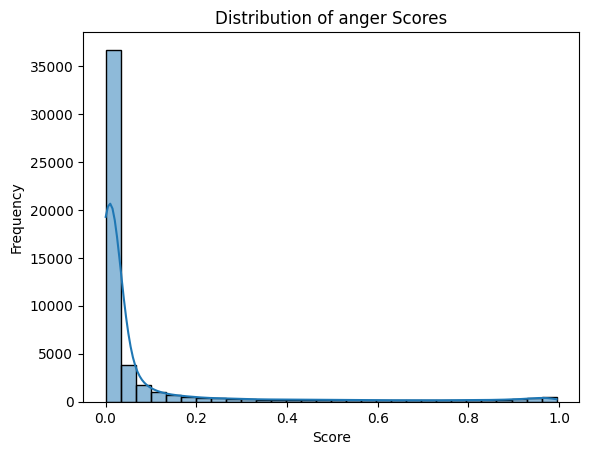

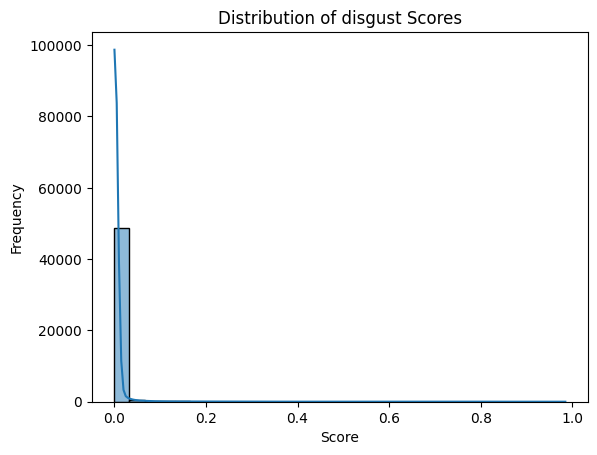

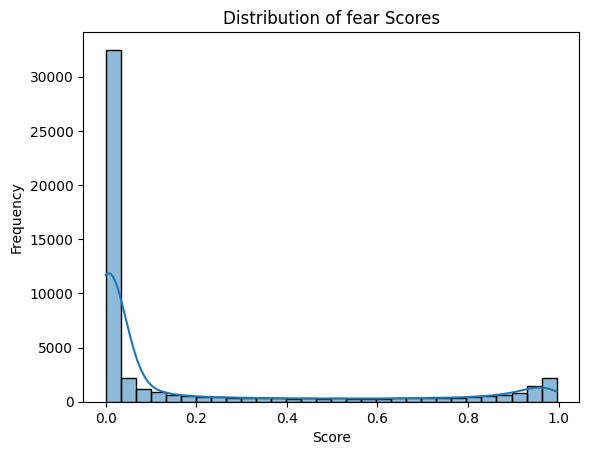

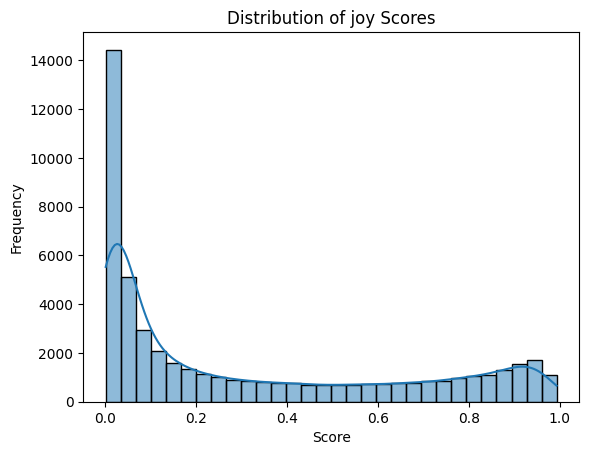

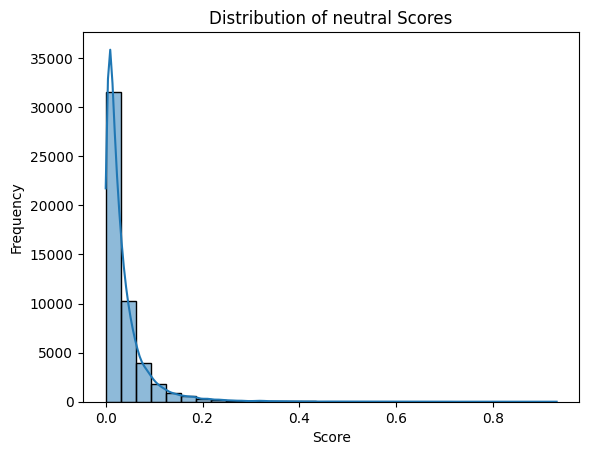

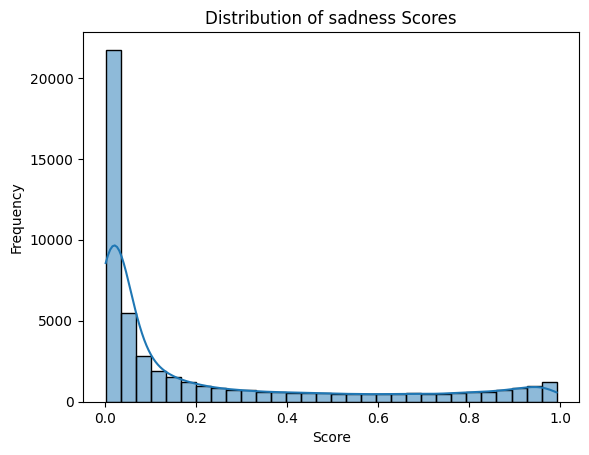

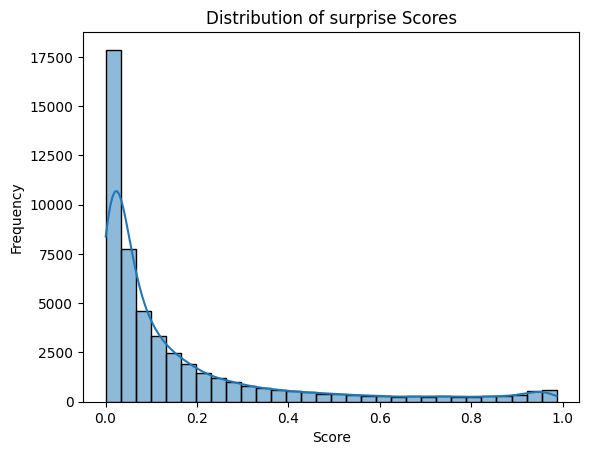

In [6]:
# Visualize emotion distribution
for label in emotion_labels:
    sns.histplot(df[label], kde=True, bins=30)
    plt.title(f'Distribution of {label} Scores')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.show()



#### 5.2 Correlation Matrix



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


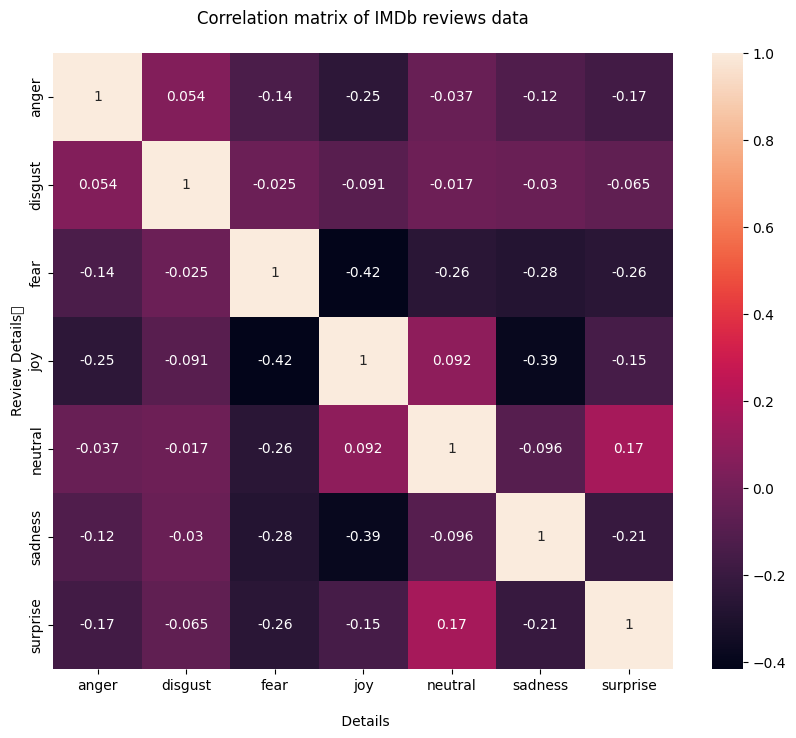

In [7]:
# Display correlation matrix
a4_dims = (10, 8)
fig, ax = plt.subplots(figsize=a4_dims)

hm = sns.heatmap(ax=ax, data=df[emotion_labels].corr(), annot=True)
hm.set(xlabel='\n Details', ylabel='Review Details\t', title="Correlation matrix of IMDb reviews data\n")

plt.show()



### 6. Text Analysis

#### 6.1 Word Frequency by Emotion



Most common words in anger reviews:
[('br', 12420), ('movie', 5704), ('film', 5479), ('one', 3408), ('like', 2608), ('character', 1897), ('time', 1867), ('would', 1758), ('even', 1712), ('get', 1689), ('make', 1608), ('good', 1567), ('people', 1496), ('story', 1419), ('see', 1372), ('scene', 1276), ('show', 1226), ('really', 1224), ('way', 1210), ('bad', 1209)]


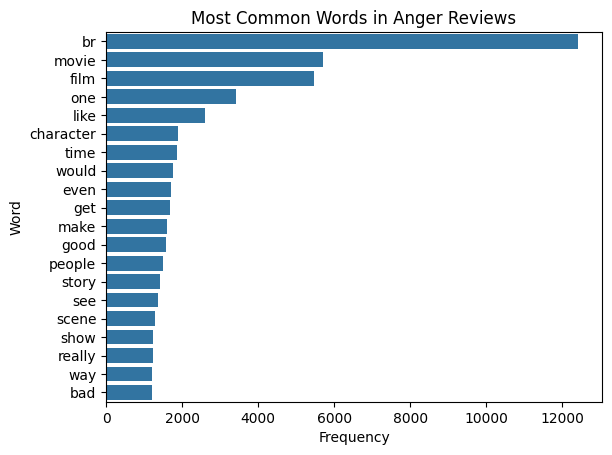

Most common words in disgust reviews:
[('br', 444), ('movie', 361), ('film', 209), ('one', 166), ('disgusting', 138), ('like', 119), ('time', 97), ('bad', 92), ('even', 88), ('show', 87), ('would', 83), ('ever', 82), ('see', 79), ('good', 71), ('make', 66), ('people', 64), ('character', 61), ('really', 59), ('thing', 59), ('scene', 58)]


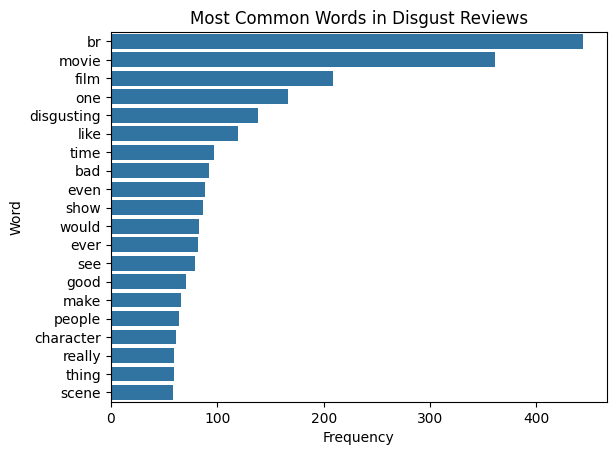

Most common words in fear reviews:
[('br', 40502), ('film', 20353), ('movie', 19430), ('one', 11728), ('like', 8420), ('time', 5974), ('horror', 5921), ('even', 5429), ('good', 5298), ('make', 5237), ('get', 5233), ('character', 5064), ('scene', 4901), ('would', 4733), ('story', 4728), ('see', 4656), ('really', 4495), ('well', 4104), ('bad', 4010), ('people', 3753)]


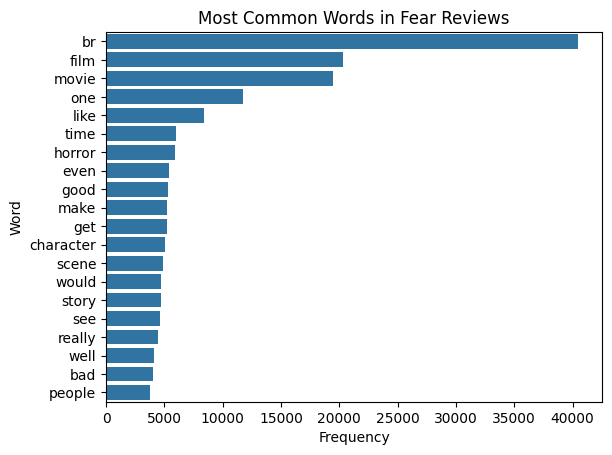

Most common words in joy reviews:
[('br', 55948), ('movie', 28719), ('film', 26276), ('one', 15191), ('like', 10876), ('good', 9405), ('time', 8980), ('character', 8412), ('story', 7419), ('great', 7097), ('well', 6927), ('see', 6774), ('make', 6521), ('get', 6466), ('really', 6214), ('would', 6183), ('even', 5740), ('scene', 5714), ('show', 5644), ('also', 5447)]


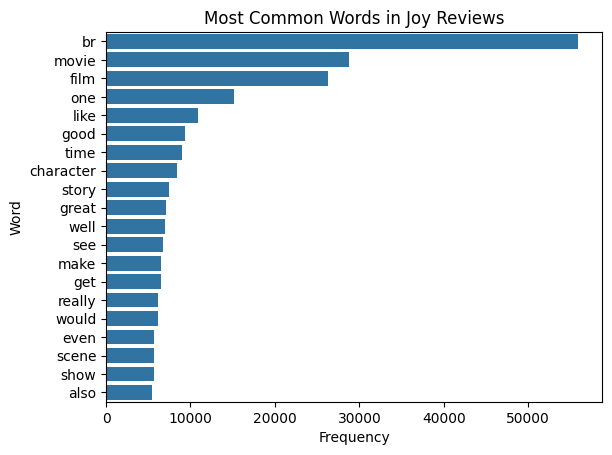

Most common words in neutral reviews:
[('movie', 43), ('br', 36), ('one', 31), ('film', 23), ('comment', 17), ('like', 16), ('good', 16), ('even', 13), ('would', 13), ('get', 13), ('plot', 12), ('character', 12), ('watch', 12), ('well', 12), ('please', 11), ('time', 11), ('story', 10), ('every', 10), ('must', 9), ('line', 9)]


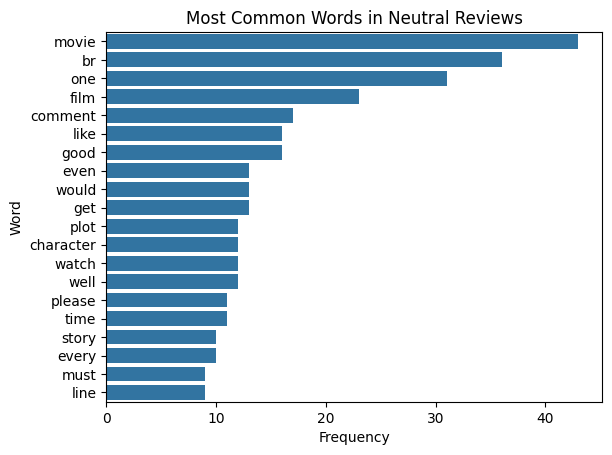

Most common words in sadness reviews:
[('br', 36888), ('movie', 19917), ('film', 16919), ('one', 9895), ('like', 7542), ('time', 5836), ('character', 5447), ('good', 5315), ('even', 4940), ('story', 4787), ('would', 4472), ('really', 4458), ('get', 4393), ('see', 4356), ('make', 4354), ('bad', 4237), ('scene', 3798), ('much', 3694), ('well', 3508), ('life', 3491)]


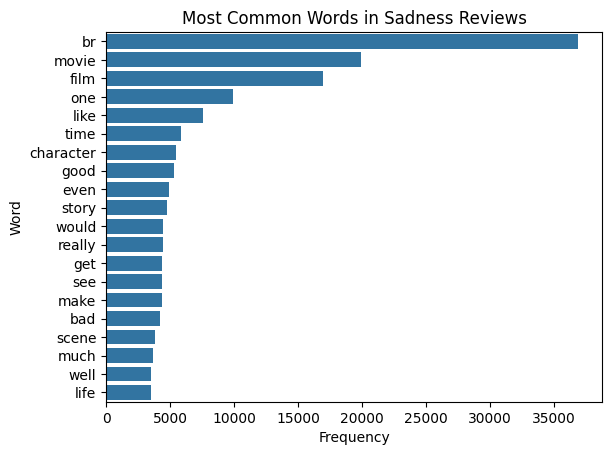

Most common words in surprise reviews:
[('br', 18412), ('movie', 10624), ('film', 8643), ('one', 5065), ('like', 3977), ('time', 3020), ('good', 2878), ('character', 2631), ('would', 2624), ('see', 2562), ('really', 2537), ('story', 2494), ('even', 2359), ('get', 2200), ('well', 2101), ('make', 2074), ('much', 1973), ('scene', 1937), ('first', 1928), ('people', 1818)]


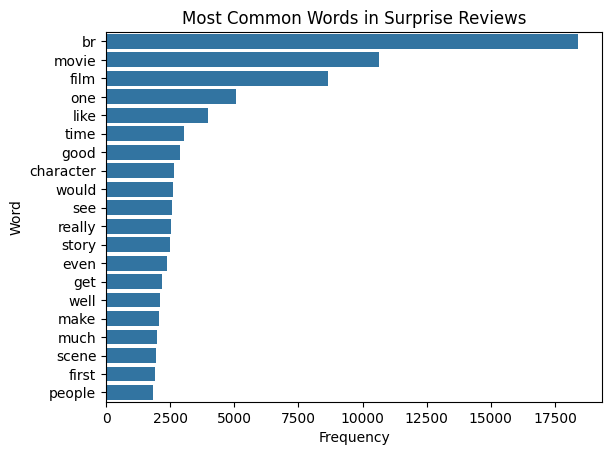

In [8]:
from collections import Counter

# Tokenize reviews
df['tokens'] = df['cleaned_review'].apply(word_tokenize)

# Count word frequency by emotion
for label in emotion_labels:
    words = df[df[label] > 0.5]['tokens'].explode()
    word_freq = Counter(words)

    # Display the 20 most common words for each emotion
    print(f"Most common words in {label} reviews:")
    print(word_freq.most_common(20))

    # Visualize most common words for each emotion
    common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
    sns.barplot(x='Frequency', y='Word', data=common_words)
    plt.title(f'Most Common Words in {label.capitalize()} Reviews')
    plt.show()



#### 6.2 Word Cloud Generation



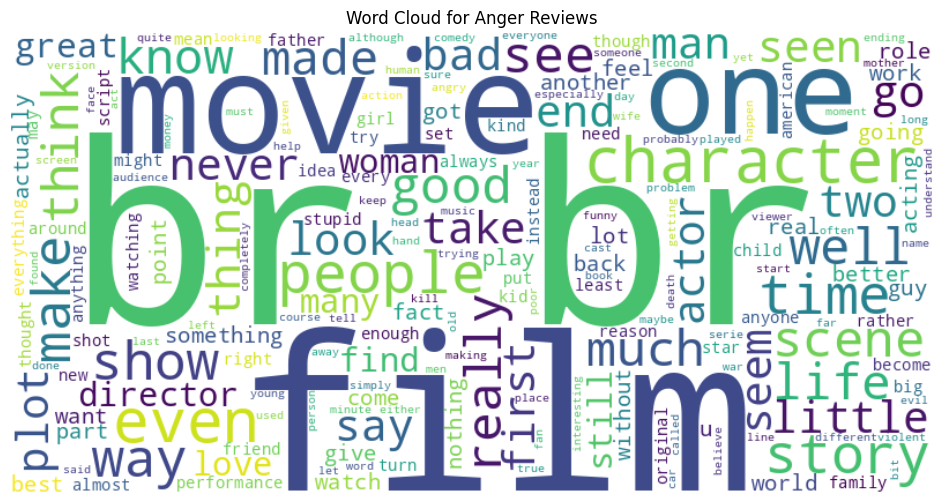

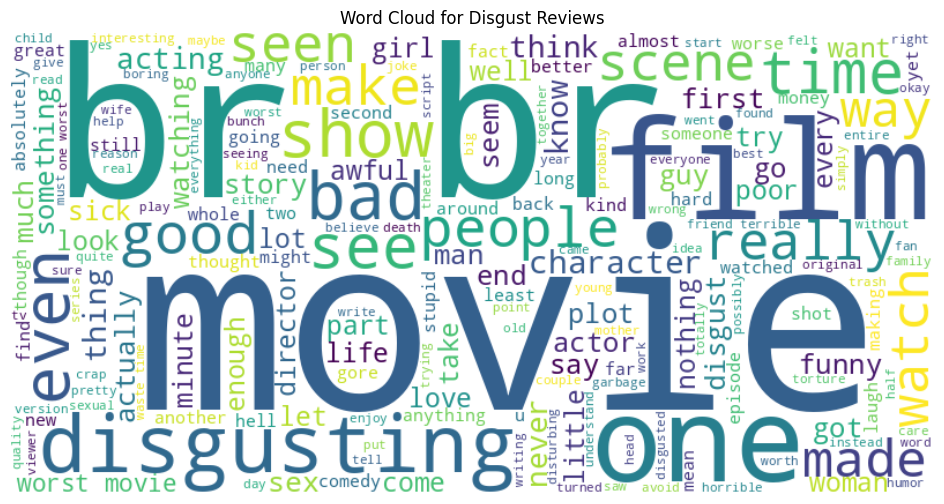

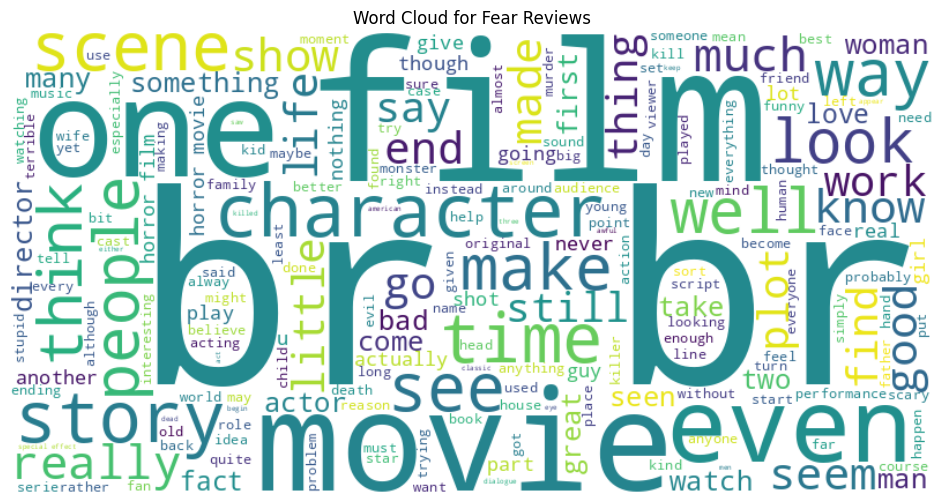

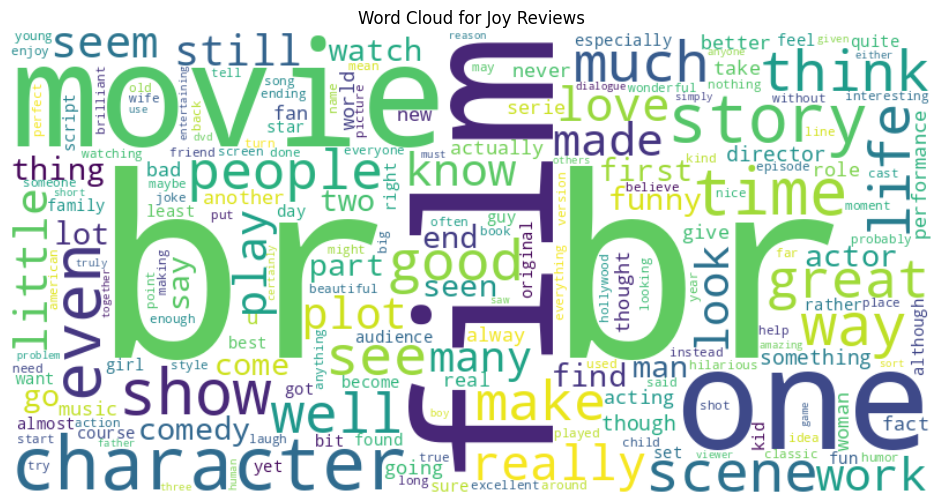

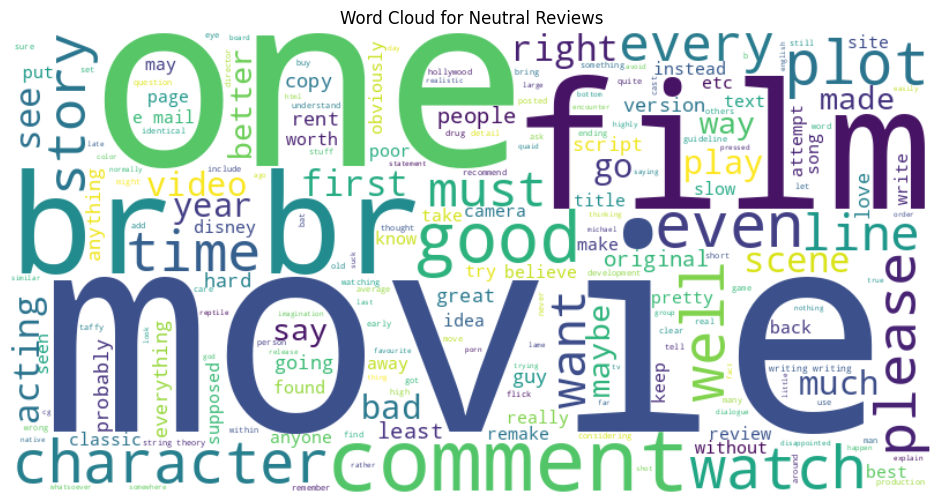

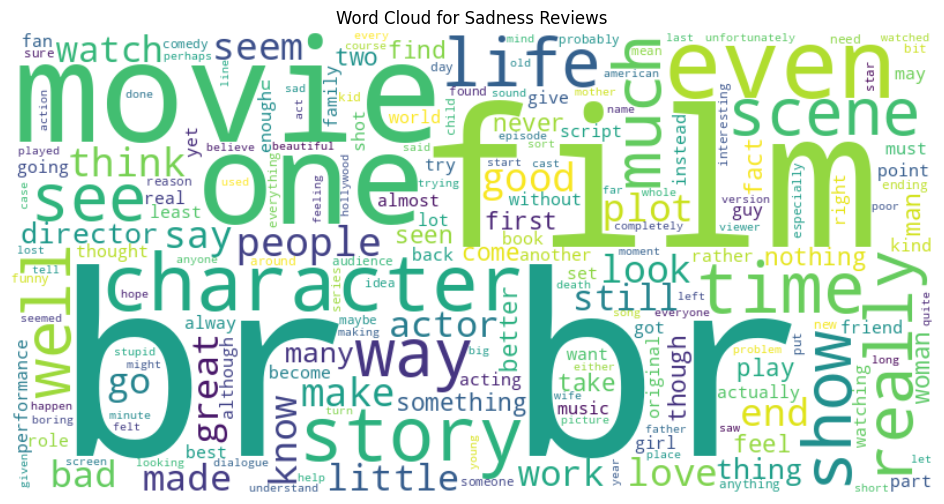

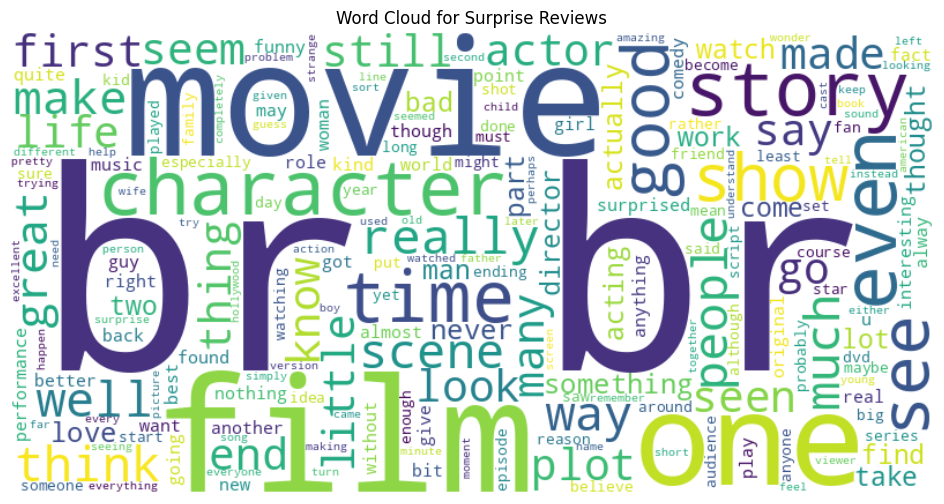

In [9]:
from wordcloud import WordCloud

# Generate word clouds by emotion
for label in emotion_labels:
    text = ' '.join(df[df[label] > 0.5]['cleaned_review'])

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {label.capitalize()} Reviews')
    plt.axis('off')
    plt.show()

### 7. Création de l'ensemble de training et de l'ensemble de test

In [17]:
!pip install tensorflow

In [18]:
# Import additional required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense
import numpy as np

In [19]:
# Convert emotions dictionary to single label
def get_dominant_emotion(emotions_dict):
    return max(eval(str(emotions_dict)).items(), key=lambda x: x[1])[0]

# Add dominant emotion column
df['dominant_emotion'] = df['emotions'].apply(get_dominant_emotion)

In [20]:
# Prepare data for traditional ML
X = df['cleaned_review']
y = df['dominant_emotion']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [21]:
from tqdm import tqdm

# Traditional ML Models Evaluation
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial'),
    'SVM': LinearSVC(multi_class='ovr'),
    'Random Forest': RandomForestClassifier()
}

results = {}

# Add progress bar for model training
for name, model in tqdm(models.items(), desc="Training traditional models"):
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f'{name} Accuracy: {acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, pred))
    print('-'*50)

Training traditional models:   0%|          | 0/4 [00:00<?, ?it/s]


Training Naive Bayes...
Naive Bayes Accuracy: 0.5093

Classification Report:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Training traditional models:  25%|██▌       | 1/4

              precision    recall  f1-score   support

       anger       0.36      0.01      0.02       767
     disgust       0.00      0.00      0.00        47
        fear       0.61      0.49      0.55      1994
         joy       0.49      0.89      0.63      3498
     neutral       0.00      0.00      0.00        42
     sadness       0.50      0.40      0.44      2358
    surprise       0.94      0.02      0.05      1294

    accuracy                           0.51     10000
   macro avg       0.41      0.26      0.24     10000
weighted avg       0.56      0.51      0.44     10000

--------------------------------------------------

Training Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: 

Logistic Regression Accuracy: 0.6116

Classification Report:
              precision    recall  f1-score   support

       anger       0.49      0.19      0.27       767
     disgust       1.00      0.06      0.12        47
        fear       0.68      0.62      0.65      1994
         joy       0.60      0.83      0.70      3498
     neutral       0.00      0.00      0.00        42
     sadness       0.57      0.57      0.57      2358
    surprise       0.67      0.39      0.49      1294

    accuracy                           0.61     10000
   macro avg       0.57      0.38      0.40     10000
weighted avg       0.61      0.61      0.59     10000

--------------------------------------------------

Training SVM...


Training traditional models:  75%|███████▌  | 3/4 [00:44<00:15, 15.48s/it]

SVM Accuracy: 0.6218

Classification Report:
              precision    recall  f1-score   support

       anger       0.43      0.29      0.34       767
     disgust       0.54      0.30      0.38        47
        fear       0.67      0.65      0.66      1994
         joy       0.64      0.79      0.71      3498
     neutral       0.00      0.00      0.00        42
     sadness       0.59      0.56      0.57      2358
    surprise       0.62      0.48      0.54      1294

    accuracy                           0.62     10000
   macro avg       0.50      0.44      0.46     10000
weighted avg       0.61      0.62      0.61     10000

--------------------------------------------------

Training Random Forest...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Training traditional models: 100%|██████████| 4/4

Random Forest Accuracy: 0.5910

Classification Report:
              precision    recall  f1-score   support

       anger       0.84      0.09      0.16       767
     disgust       0.50      0.04      0.08        47
        fear       0.67      0.64      0.65      1994
         joy       0.55      0.86      0.67      3498
     neutral       0.00      0.00      0.00        42
     sadness       0.58      0.50      0.53      2358
    surprise       0.81      0.30      0.44      1294

    accuracy                           0.59     10000
   macro avg       0.56      0.35      0.36     10000
weighted avg       0.63      0.59      0.56     10000

--------------------------------------------------


In [23]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [24]:
# For LSTM, we can use a custom callback to show progress
from tensorflow import keras
from tensorflow.keras.callbacks import Callback

class CustomProgress(Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch
        print(f"\nEpoch {epoch + 1}/5")
        self.progbar = tqdm(total=self.params['steps'],
                           desc=f"Training LSTM",
                           unit='batch')

    def on_batch_end(self, batch, logs=None):
        self.progbar.update(1)
        self.progbar.set_postfix({'loss': f"{logs['loss']:.4f}",
                                 'accuracy': f"{logs['accuracy']:.4f}"})

    def on_epoch_end(self, epoch, logs=None):
        self.progbar.close()
        print(f"val_loss: {logs['val_loss']:.4f} - val_accuracy: {logs['val_accuracy']:.4f}")

In [25]:
# Deep Learning Model (LSTM)
# Tokenization
max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Convert labels to numerical format
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Convert to categorical
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)

In [26]:
# LSTM Model
model = Sequential()
model.add(Embedding(max_words, 128, input_length=max_len))
model.add(SpatialDropout1D(0.4))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(len(le.classes_), activation='softmax'))  # Number of emotion classes

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
print("\nTraining LSTM model...")
# Train model
history = model.fit(X_train_pad, y_train_cat,
                   epochs=5,
                   batch_size=64,
                   validation_split=0.1,
                   callbacks=[CustomProgress()])


Training LSTM model...

Epoch 1/5


Training LSTM:   0%|          | 0/563 [00:00<?, ?batch/s]

Epoch 1/5


Training LSTM:   0%|          | 1/563 [00:12<1:52:38, 12.03s/batch, loss=1.9483, accuracy=0.0781]

  1/563 ━━━━━━━━━━━━━━━━━━━━ 1:52:40 12s/step - accuracy: 0.0781 - loss: 1.9483

...

562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5679 - loss: 1.1767

Training LSTM: 100%|██████████| 563/563 [04:28<00:00,  2.62batch/s, loss=1.1745, accuracy=0.5683]

563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5679 - loss: 1.1767

Training LSTM: 100%|██████████| 563/563 [04:33<00:00,  2.06batch/s, loss=1.1745, accuracy=0.5683]

val_loss: 1.2581 - val_accuracy: 0.5485
563/563 ━━━━━━━━━━━━━━━━━━━━ 273s 451ms/step - accuracy: 0.5679 - loss: 1.1767 - val_accuracy: 0.5485 - val_loss: 1.2581


In [28]:
# Evaluate LSTM
lstm_acc = model.evaluate(X_test_pad, y_test_cat)[1]
results['LSTM'] = lstm_acc
print(f'\nLSTM Accuracy: {lstm_acc:.4f}')

# Predict with LSTM for detailed report
lstm_pred = model.predict(X_test_pad)
lstm_pred_classes = le.inverse_transform(np.argmax(lstm_pred, axis=1))
print('\nLSTM Classification Report:')
print(classification_report(y_test, lstm_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.5471 - loss: 1.2571

LSTM Accuracy: 0.5459
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

       anger       0.27      0.04      0.07       767
     disgust       0.00      0.00      0.00        47
        fear       0.59      0.74      0.66      1994
         joy       0.56      0.80      0.66      3498
     neutral       1.00      0.02      0.05        42
     sadness       0.49      0.45      0.47      2358
    surprise       0.35      0.08      0.13      1294

    accuracy                           0.55     10000
   macro avg       0.47      0.30      0.29     10000
weighted avg       0.50      0.55      0.49     10000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


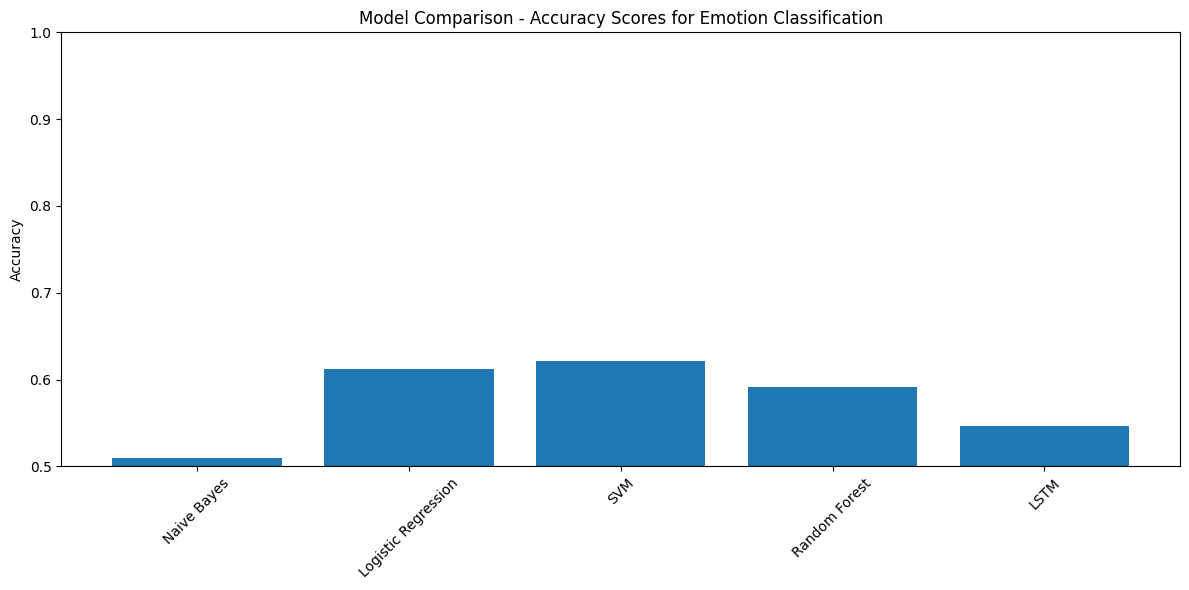

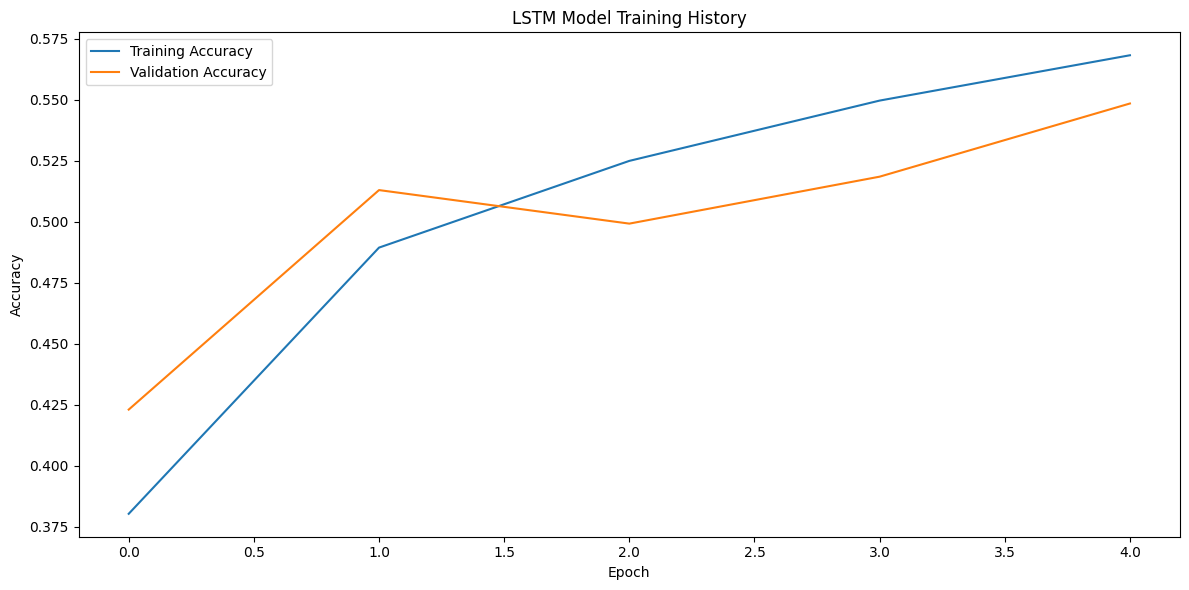

In [29]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(results.keys(), results.values())
plt.title('Model Comparison - Accuracy Scores for Emotion Classification')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot LSTM training history
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()